In [ ]:
!pip install econml mlflow skimpy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.stats as ss
import statsmodels.tsa as ts #Baseline Models (Probably GARCH, ARIMA or SARIMAX)
import mlflow
import mlflow.sklearn
import skimpy as sk
import imblearn.over_sampling as io

from sklearn.preprocessing import *
from sklearn.impute import SimpleImputer
from sklearn.metrics import *
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor #Last Resort
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit, cross_val_predict#Everything's research backed btw
from sklearn.pipeline import Pipeline
from sklearn.base import clone


import joblib
from warnings import filterwarnings
filterwarnings("ignore")

In [ ]:
train_df = pd.read_csv("/content/raw_train.csv")
test_df = pd.read_csv("/content/raw_test.csv")

In [ ]:
train_df.isnull().sum()

,0
quantity,0
amount,0
job_category_description,0
bid_date,0
total_bid,0
num_pay_items,0
pay_item_description,0
unit_english_id,2
category_id,0
category_description,0


In [ ]:
sk.skim(train_df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 832056 │ │ string      │ 10    │                                                          │
│ │ Number of columns │ 15     │ │ float64     │ 3     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column         ┃ NA ┃ NA % ┃ mean    ┃ sd       ┃ p0    ┃ p25     ┃ p50     ┃ p75     ┃ p100      ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━┩  │
│ │ quantity       │  0 │    0 │    3571 │    30940 │  0.01 │       2 │      35 │     450 │   6010000 │   █    │  │
│ │ amount         │  0 │    0 │   11540 │   325000 │  0.01 │       6 │      80 │     850 │  97880000 │   █    │  │
│ │ total_bid      │  0 │    0 │ 7743000 │ 24810000 │ 12860 │ 1278000 │ 2657000 │ 6000000 │ 409000000 │   █    │  │
│ │ num_pay_items  │  0 │    0 │   116.2 │    80.42 │     3 │      70 │      99 │     140 │       769 │   █▃   │  │
│ │ category_id    │  0 │    0 │   13.57 │    9.612 │     0 │       5 │      12 │      19 │        31 │ █▇▃▅▂▅ │  │
│ └────────────────┴────┴──────┴─────────┴──────────┴───────┴─────────┴─────────┴─────────┴───────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃           ┃    ┃           ┃          ┃           ┃          ┃           ┃ chars    ┃ words per ┃ total    ┃  │
│ ┃ column    ┃ NA ┃ NA %      ┃ shortest ┃ longest   ┃ min      ┃ max       ┃ per row  ┃ row       ┃ words    ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ job_categ │  0 │         0 │ BRIDGE   │ STRIPING/ │ ASPHALT  │ Uncategor │     9.25 │       1.1 │   935848 │  │
│ │ ory_descr │    │           │          │ PAVEMENT  │          │ ized      │          │           │          │  │
│ │ iption    │    │           │          │ MARKING   │          │ Project   │          │           │          │  │
│ │ bid_date  │  0 │         0 │ 2018-01- │ 2018-01-1 │ 2018-01- │ 2024-12-1 │       10 │         1 │   832056 │  │
│ │           │    │           │ 18       │ 8         │ 18       │ 1         │          │           │          │  │
│ │ pay_item_ │  0 │         0 │ CAP      │ ET_2000   │ ACCESSIB │ WIRELESS  │       27 │       4.1 │  3392277 │  │
│ │ descripti │    │           │          │ OS UNIT   │ LE       │ REPEATER  │          │           │          │  │
│ │ on        │    │           │          │ COMPLETE  │ PEDESTRI │           │          │           │          │  │
│ │           │    │           │          │ WITHOUT   │ AN       │           │          │           │          │  │
│ │           │    │           │          │ FOUNDATIO │ SYSTEM   │           │          │           │          │  │
│ │           │    │           │          │ N TUBES   │ 

In [ ]:
train_df

,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.00,7000.00,BRIDGE,2018-01-18,453231.70,55,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_002829,CON_000015,LOC_000091,ITEM_003580,JOB_002829__CON_000015
1,1.00,11000.00,BRIDGE,2018-01-18,148876.00,20,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001298,CON_000015,LOC_000028,ITEM_003580,JOB_001298__CON_000015
2,1.00,24000.00,BRIDGE,2018-01-18,1513003.05,101,CONSTRUCTION ENGINEERING,EACH,25,MOBILIZATION,JOB_001294,CON_000015,LOC_000028,ITEM_003580,JOB_001294__CON_000015
3,1.00,1.00,BRIDGE,2018-01-18,453231.70,55,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_002829,CON_000015,LOC_000091,ITEM_003537,JOB_002829__CON_000015
4,1.00,1.00,BRIDGE,2018-01-18,1513003.05,101,LIQUIDATED DAMAGES,$,31,ALTERNATES/BONUS/TIME,JOB_001294,CON_000015,LOC_000028,ITEM_003537,JOB_001294__CON_000015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832051,1.00,47600.00,CLEARING,2024-12-11,952000.00,10,MOBILIZATION AND DEMOBILIZATION,EACH,25,MOBILIZATION,JOB_003140,CON_000137,LOC_000010,ITEM_000561,JOB_003140__CON_000137
832052,18.00,40000.00,CLEARING,2024-12-11,952000.00,10,CLEARING AND GRUBBING,EACH,13,CLEARING,JOB_003140,CON_000137,LOC_000010,ITEM_003868,JOB_003140__CON_000137
832053,41107.12,1.00,CLEARING,2024-12-11,952000.00,10,STORM WATER MANAGEMENT BUDGET,$,24,BUILDINGS/MISC STRUCTURES,JOB_003140,CON_000137,LOC_000010,ITEM_002818,JOB_003140__CON_000137
832054,1.00,50000.00,CLEARING,2024-12-11,952000.00,10,STORMWATER MANAGEMENT IMPLEMENTATION,EACH,6,DRAINAGE-INLETS/CATCH BASINS,JOB_003140,CON_000137,LOC_000010,ITEM_003367,JOB_003140__CON_000137


## Exploratory Data Analysis

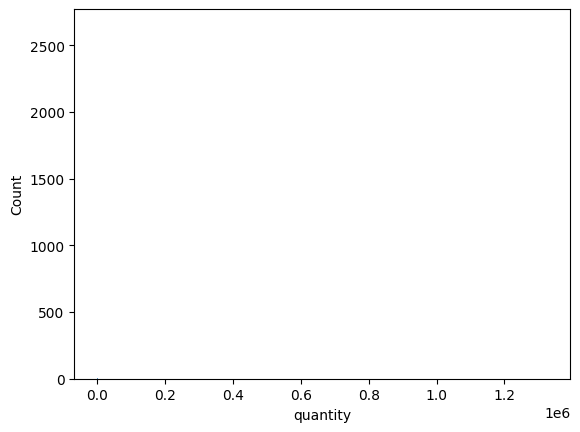

In [ ]:
#Quantity Distribution
sns.histplot(train_df["quantity"].iloc[1:5000])
#plt.savefig("Quantity Distribution")
plt.show()

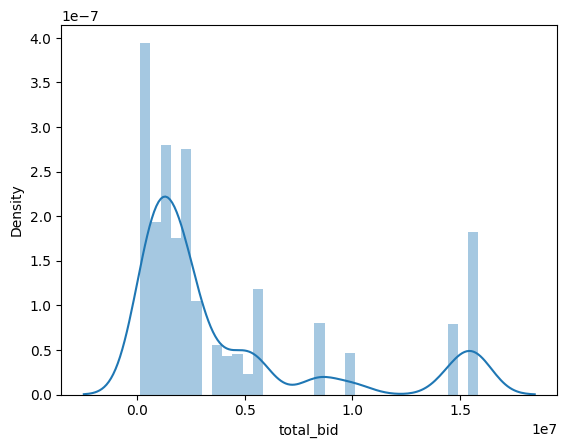

In [ ]:
#Bidding Distribution (Seeing if Oversampling methods is possible)
sns.distplot(train_df["total_bid"].iloc[1:5000])
#plt.savefig("Price Bid Distribution")
plt.show()

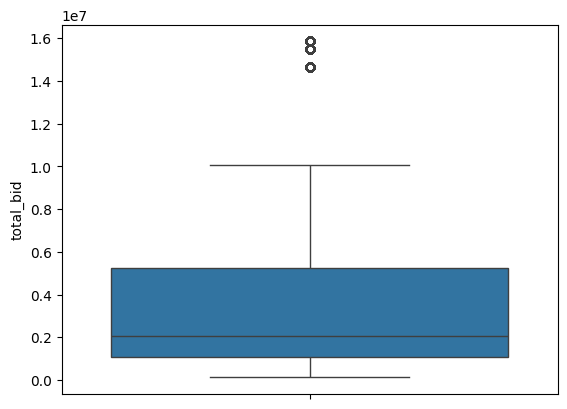

In [ ]:
#POssible Outliers
sns.boxplot(train_df["total_bid"].iloc[1:5000])
#plt.savefig("Bidding Outliers")
plt.show()

##Feature Engineering

In [ ]:
encoder = LabelEncoder()
train_df["job_category_description"] = encoder.fit_transform(train_df[["job_category_description"]])
train_df["pay_item_description"] = encoder.fit_transform(train_df[["pay_item_description"]])
train_df["category_description"] = encoder.fit_transform(train_df[["category_description"]])
train_df["contractor_id"] = encoder.fit_transform(train_df[["contractor_id"]])
train_df["primary_location"] = encoder.fit_transform(train_df[["primary_location"]])
train_df["unit_english_id"] = encoder.fit_transform(train_df[["unit_english_id"]])
train_df

,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,job_id,contractor_id,primary_location,pay_item_id,row_id
0,1.00,7000.00,1,2018-01-18,453231.70,55,475,6,25,18,JOB_002829,13,90,ITEM_003580,JOB_002829__CON_000015
1,1.00,11000.00,1,2018-01-18,148876.00,20,475,6,25,18,JOB_001298,13,27,ITEM_003580,JOB_001298__CON_000015
2,1.00,24000.00,1,2018-01-18,1513003.05,101,475,6,25,18,JOB_001294,13,27,ITEM_003580,JOB_001294__CON_000015
3,1.00,1.00,1,2018-01-18,453231.70,55,1534,0,31,0,JOB_002829,13,90,ITEM_003537,JOB_002829__CON_000015
4,1.00,1.00,1,2018-01-18,1513003.05,101,1534,0,31,0,JOB_001294,13,27,ITEM_003537,JOB_001294__CON_000015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
832051,1.00,47600.00,3,2024-12-11,952000.00,10,1736,6,25,18,JOB_003140,132,9,ITEM_000561,JOB_003140__CON_000137
832052,18.00,40000.00,3,2024-12-11,952000.00,10,325,6,13,5,JOB_003140,132,9,ITEM_003868,JOB_003140__CON_000137
832053,41107.12,1.00,3,2024-12-11,952000.00,10,3040,0,24,4,JOB_003140,132,9,ITEM_002818,JOB_003140__CON_000137
832054,1.00,50000.00,3,2024-12-11,952000.00,10,3041,6,6,9,JOB_003140,132,9,ITEM_003367,JOB_003140__CON_000137


In [ ]:
train_df = train_df.drop(columns=["row_id", "job_id"], axis=1)
train_df

,quantity,amount,job_category_description,bid_date,total_bid,num_pay_items,pay_item_description,unit_english_id,category_id,category_description,contractor_id,primary_location,pay_item_id
0,1.00,7000.00,1,2018-01-18,453231.70,55,475,6,25,18,13,90,ITEM_003580
1,1.00,11000.00,1,2018-01-18,148876.00,20,475,6,25,18,13,27,ITEM_003580
2,1.00,24000.00,1,2018-01-18,1513003.05,101,475,6,25,18,13,27,ITEM_003580
3,1.00,1.00,1,2018-01-18,453231.70,55,1534,0,31,0,13,90,ITEM_003537
4,1.00,1.00,1,2018-01-18,1513003.05,101,1534,0,31,0,13,27,ITEM_003537
...,...,...,...,...,...,...,...,...,...,...,...,...,...
832051,1.00,47600.00,3,2024-12-11,952000.00,10,1736,6,25,18,132,9,ITEM_000561
832052,18.00,40000.00,3,2024-12-11,952000.00,10,325,6,13,5,132,9,ITEM_003868
832053,41107.12,1.00,3,2024-12-11,952000.00,10,3040,0,24,4,132,9,ITEM_002818
832054,1.00,50000.00,3,2024-12-11,952000.00,10,3041,6,6,9,132,9,ITEM_003367


In [ ]:
def build_research_features(df):

    df = df.copy()

    # -----------------------------
    # 1️⃣ Basic Cleaning
    # -----------------------------

    df["bid_date"] = pd.to_datetime(df["bid_date"])
    df = df.sort_values("bid_date")

    # log target for RMSLE
    df["log_total_bid"] = np.log1p(df["total_bid"])

    # -----------------------------
    # 2️⃣ Temporal Features
    # -----------------------------

    df["year"] = df["bid_date"].dt.year
    df["month"] = df["bid_date"].dt.month
    df["quarter"] = df["bid_date"].dt.quarter
    df["day_of_year"] = df["bid_date"].dt.dayofyear

    # Continuous time index
    min_date = df["bid_date"].min()
    df["time_index"] = (df["bid_date"] - min_date).dt.days

    # -----------------------------
    # 3️⃣ Line-Level Derived Features
    # -----------------------------

    df["line_total"] = df["quantity"] * df["amount"]

    # Price intensity proxy
    df["log_amount"] = np.log1p(df["amount"])
    df["log_quantity"] = np.log1p(df["quantity"])

    # -----------------------------
    # 4️⃣ Aggregate to Contractor–Job Level
    # -----------------------------

    agg_dict = {
        "line_total": ["sum", "mean", "std"],
        "quantity": ["sum", "mean", "std"],
        "amount": ["mean", "std"],
        "pay_item_id": "nunique",
        "category_id": "nunique",
        "num_pay_items": "first",
        "log_total_bid": "first",
        "year": "first",
        "month": "first",
        "quarter": "first",
        "time_index": "first",
        "contractor_id": "first",
        "primary_location": "first"
    }

    grouped = df.groupby(["contractor_id", "primary_location", "time_index"]).agg(agg_dict)

    grouped.columns = ["_".join(col).strip() for col in grouped.columns.values]
    grouped = grouped.reset_index()

    # Rename for clarity
    grouped.rename(columns={
        "log_total_bid_first": "log_total_bid",
        "pay_item_id_nunique": "unique_pay_items",
        "category_id_nunique": "unique_categories"
    }, inplace=True)

    # -----------------------------
    # 5️⃣ Job Complexity Proxies
    # -----------------------------

    grouped["complexity_ratio"] = (
        grouped["unique_pay_items"] /
        (grouped["num_pay_items_first"] + 1)
    )

    grouped["line_total_cv"] = (
        grouped["line_total_std"] /
        (grouped["line_total_mean"] + 1)
    )

    grouped["quantity_cv"] = (
        grouped["quantity_std"] /
        (grouped["quantity_mean"] + 1)
    )

    # -----------------------------
    # 6️⃣ Contractor Historical Features (Time-Safe)
    # -----------------------------

    grouped = grouped.sort_values("time_index")

    grouped["contractor_rolling_mean"] = (
        grouped.groupby("contractor_id")["log_total_bid"]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    )

    grouped["contractor_rolling_std"] = (
        grouped.groupby("contractor_id")["log_total_bid"]
        .transform(lambda x: x.shift(1).rolling(5, min_periods=1).std())
    )

    grouped["contractor_bid_count"] = (
        grouped.groupby("contractor_id").cumcount()
    )

    grouped["days_since_last_bid"] = (
        grouped.groupby("contractor_id")["time_index"]
        .diff()
    )

    # Fill missing historical values
    grouped.fillna(0)

    return grouped

In [ ]:
train_df = build_research_features(train_df)


In [ ]:
train_df

,contractor_id,primary_location,time_index,line_total_sum,line_total_mean,line_total_std,quantity_sum,quantity_mean,quantity_std,amount_mean,...,time_index_first,contractor_id_first,primary_location_first,complexity_ratio,line_total_cv,quantity_cv,contractor_rolling_mean,contractor_rolling_std,contractor_bid_count,days_since_last_bid
7018,182,17,0,4741613.900,25910.458470,66233.254426,327845.20,1791.503825,9090.743309,7125.735738,...,0,182,17,1.042735,2.556138,5.071534,NaN,NaN,0,NaN
8003,188,29,0,1211675.250,11015.229545,19041.783974,55182.00,501.654545,2992.237031,2604.959545,...,0,188,29,0.981982,1.728521,5.952870,NaN,NaN,0,NaN
3231,84,64,0,4317800.000,32710.606061,61754.386607,239854.00,1817.075758,5459.337799,5680.922727,...,0,84,64,0.969925,1.887843,3.002811,NaN,NaN,0,NaN
3238,84,79,0,2686394.990,30184.213371,81501.831074,122532.70,1376.771910,7954.187289,4388.431011,...,0,84,79,0.966667,2.700058,5.773225,15.278257,NaN,1,0.0
3190,83,76,0,354878.000,16898.952381,61773.154198,8370.00,398.571429,1327.785207,2536.904762,...,0,83,76,0.954545,3.655227,3.323023,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3414,93,48,2519,162723.080,9571.945882,12460.154879,577.00,33.941176,73.508053,5528.645882,...,2519,93,48,0.944444,1.301601,2.103766,12.521426,1.340779,36,0.0
5586,153,29,2519,3234434.240,38505.169524,94580.093761,82479.03,981.893214,3541.880968,9285.131905,...,2519,153,29,0.976471,2.456232,3.603526,14.884727,1.674907,901,0.0
5614,153,34,2519,1684133.920,20791.776790,56126.855933,86066.50,1062.549383,6223.464064,3870.065432,...,2519,153,34,0.987805,2.699344,5.851599,15.294600,1.285521,902,0.0
6712,172,46,2519,412368.228,7780.532604,14120.131893,13985.13,263.870377,600.536795,2293.560755,...,2519,172,46,0.981481,1.814570,2.267286,13.986652,0.530173,72,0.0


## Test Set Feature Engineering

In [ ]:
def extract_contractor_state(train_features):

    contractor_state = (
        train_features
        .sort_values("time_index_first")
        .groupby("contractor_id")
        .last()[[
            "contractor_rolling_mean",
            "contractor_rolling_std",
            "contractor_bid_count",
            "time_index_first"
        ]]
        .reset_index()
    )

    contractor_state.rename(columns={
        "time_index_first": "last_train_time_index"
    }, inplace=True)

    return contractor_state


In [ ]:
def build_test_features(df, contractor_state, train_min_date):

    df = df.copy()

    df["bid_date"] = pd.to_datetime(df["bid_date"])
    df = df.sort_values("bid_date")

    # -----------------------------
    # Temporal
    # -----------------------------

    df["year"] = df["bid_date"].dt.year
    df["month"] = df["bid_date"].dt.month
    df["quarter"] = df["bid_date"].dt.quarter
    df["day_of_year"] = df["bid_date"].dt.dayofyear

    df["time_index"] = (df["bid_date"] - train_min_date).dt.days

    # -----------------------------
    # Structural
    # -----------------------------

    df["log_quantity"] = np.log1p(df["quantity"])

    # -----------------------------
    # Aggregate EXACTLY like train
    # -----------------------------

    agg_dict = {
        "quantity": ["sum", "mean", "std"],
        "pay_item_id": "nunique",
        "category_id": "nunique",
        "num_pay_items": "first",
        "year": "first",
        "month": "first",
        "quarter": "first",
        "time_index": "first",
        "primary_location": "first"
    }

    grouped = df.groupby(["contractor_id", "job_id"]).agg(agg_dict)

    grouped.columns = ["_".join(col).strip() for col in grouped.columns.values]
    grouped = grouped.reset_index()

    grouped.rename(columns={
        "pay_item_id_nunique": "unique_pay_items",
        "category_id_nunique": "unique_categories"
    }, inplace=True)

    # -----------------------------
    # Add missing TRAIN-only columns
    # -----------------------------

    # These existed in train but not test
    grouped["line_total_sum"] = 0
    grouped["line_total_mean"] = 0
    grouped["line_total_std"] = 0
    grouped["amount_mean"] = 0
    grouped["amount_std"] = 0
    grouped["primary_location"] = 0
    grouped["time_index"] = 0
    grouped["contractor_id_first"] = 0
    # -----------------------------
    # Complexity features
    # -----------------------------

    grouped["complexity_ratio"] = (
        grouped["unique_pay_items"] /
        (grouped["num_pay_items_first"] + 1)
    )

    grouped["line_total_cv"] = 0
    grouped["quantity_cv"] = (
        grouped["quantity_std"] /
        (grouped["quantity_mean"] + 1)
    )

    # -----------------------------
    # Merge contractor historical state
    # -----------------------------

    grouped = grouped.merge(
        contractor_state,
        on="contractor_id",
        how="left"
    )

    # days since last train bid
    grouped["days_since_last_bid"] = (
        grouped["time_index_first"] -
        grouped["last_train_time_index"]
    )

    grouped.fillna(0, inplace=True)

    # -----------------------------
    # Drop helper column
    # -----------------------------

    grouped.drop(columns=["last_train_time_index"], inplace=True)

    return grouped


In [ ]:
orig_train_df = pd.read_csv("/content/raw_train.csv")

#Extraction from training_data
contractor_state = (
    train_df
    .sort_values("time_index_first")
    .groupby("contractor_id")
    .last()[[
        "contractor_rolling_mean",
        "contractor_rolling_std",
        "contractor_bid_count",
        "time_index_first"
    ]]
    .reset_index()
    .rename(columns={"time_index_first": "last_train_time_index"})
)


#Forcing Merge
test_df["contractor_id"] = test_df["contractor_id"].astype(str)
contractor_state["contractor_id"] = contractor_state["contractor_id"].astype(str)

train_min_date = orig_train_df["bid_date"].min()
train_min_date = pd.to_datetime(orig_train_df["bid_date"].min())

test_df = build_test_features(test_df, contractor_state, train_min_date)



#Assigning

KeyError: 'bid_date'

In [ ]:
test_df

,contractor_id,job_id,quantity_sum,quantity_mean,quantity_std,unique_pay_items,unique_categories,num_pay_items_first,year_first,month_first,...,primary_location,time_index,contractor_id_first,complexity_ratio,line_total_cv,quantity_cv,contractor_rolling_mean,contractor_rolling_std,contractor_bid_count,days_since_last_bid
0,CON_000001,JOB_000584,83848.00,1148.602740,6665.524545,72,17,73,2025,9,...,0,0,0,0.972973,0,5.798111,0.0,0.0,0.0,0.0
1,CON_000001,JOB_000677,255113.00,4724.314815,20070.936980,34,9,54,2025,7,...,0,0,0,0.618182,0,4.247534,0.0,0.0,0.0,0.0
2,CON_000001,JOB_000803,26159.45,363.325694,1694.292790,72,20,72,2025,10,...,0,0,0,0.986301,0,4.650489,0.0,0.0,0.0,0.0
3,CON_000001,JOB_000952,26973.00,870.096774,3578.253963,30,7,31,2025,9,...,0,0,0,0.937500,0,4.107757,0.0,0.0,0.0,0.0
4,CON_000001,JOB_001090,107453.30,1628.080303,10006.584811,65,18,66,2025,12,...,0,0,0,0.970149,0,6.142475,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1442,CON_000236,JOB_000854,37487.75,646.340517,1564.833576,58,18,58,2025,1,...,0,0,0,0.983051,0,2.417327,0.0,0.0,0.0,0.0
1443,CON_000236,JOB_001113,60168.70,925.672308,2896.462258,65,20,65,2025,11,...,0,0,0,0.984848,0,3.125660,0.0,0.0,0.0,0.0
1444,CON_000236,JOB_001363,104712.00,969.555556,7081.014463,108,23,108,2025,3,...,0,0,0,0.990826,0,7.295836,0.0,0.0,0.0,0.0
1445,CON_000236,JOB_002454,280616.58,1690.461325,8321.998635,160,24,166,2025,12,...,0,0,0,0.958084,0,4.920005,0.0,0.0,0.0,0.0


In [ ]:
job_encoder = LabelEncoder()
test_df["job_id"] = job_encoder.fit_transform(test_df[["job_id"]])
test_df["contractor_id"] = job_encoder.fit_transform(test_df[["contractor_id"]])
test_df["primary_location_first"] = job_encoder.fit_transform(test_df[["primary_location_first"]])

In [ ]:
#Sanity Check
print([cols for cols in train_df.columns if cols not in test_df.columns])

['log_total_bid']


## Modelling

In [ ]:
X = train_df.drop(columns=["log_total_bid"], axis=1)
y = train_df["log_total_bid"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
enet = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", ElasticNet(
        alpha=0.001,
        l1_ratio=0.1,
        max_iter=10000
    ))
])

ridge = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", Ridge(
        alpha=0.001,
        max_iter=10000
    ))
])

gbr = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", GradientBoostingRegressor(
      learning_rate=0.03,
      n_estimators=1000,
      max_depth=4,
      subsample=0.8,
      min_samples_leaf=10
  ))
])

rfr = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
      n_estimators=1000,
      max_depth=15,
      min_samples_leaf=10,
      max_features="sqrt",
      n_jobs=-1
    ))
])

xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", XGBRegressor(
      n_estimators=2000,
      learning_rate=0.03,
      max_depth=6,
      min_child_weight=10,
      subsample=0.8,
      colsample_bytree=0.8,
      gamma=0.1,
      reg_alpha=1.0,
      reg_lambda=5.0,
      objective="reg:squarederror",
      tree_method="hist",
      random_state=42
  ))
])

lgb = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler()),
    ("model", LGBMRegressor(
      n_estimators=3000,
      learning_rate=0.02,
      num_leaves=31,
      max_depth=-1,
      min_child_samples=20,
      subsample=0.8,
      colsample_bytree=0.8,
      reg_alpha=1.0,
      reg_lambda=5.0,
      objective="regression",
      random_state=42
  ))
])

In [ ]:
#Custom Metric
def rmsle_from_log(y_true_log, y_pred_log):
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))

In [ ]:
models = {
    "Elastic_Net": enet,
    "Ridge": ridge,
    "GradientBoostingRegressor": gbr,
    "RandomForestRegressor": rfr,
    "XGBRegressor": xgb,
    "LGBMRegressor": lgb
}

with mlflow.start_run(run_name="Bid_Prediction_Experiment"):

    for model_name, model in models.items():

        with mlflow.start_run(run_name=model_name, nested=True):

            model.fit(X_train, Y_train)

            Y_pred = model.predict(X_test)

            mse = mean_squared_error(Y_test, Y_pred)
            rmse = np.sqrt(mse)
            rmsle_score = rmsle_from_log(Y_test, Y_pred)
            r2 = r2_score(Y_test, Y_pred)

            print(f"{model_name}'s Results:\n")
            print(f"MSE: {mse:.2f}")
            print(f"RMSE: {rmse:.2f}")
            print(f"RMSLE: {rmsle_score:.5f}")
            print(f"R2: {r2:.4f}\n")

            mlflow.log_param("model", model_name)
            mlflow.log_metric("mse", mse)
            mlflow.log_metric("rmse", rmse)
            mlflow.log_metric("rmsle", rmsle_score)
            mlflow.log_metric("r2", r2)

Elastic_Net's Results:

MSE: 0.30
RMSE: 0.55
RMSLE: 0.54976
R2: 0.8039

Ridge's Results:

MSE: 0.28
RMSE: 0.53
RMSLE: 0.52549
R2: 0.8209

GradientBoostingRegressor's Results:

MSE: 0.03
RMSE: 0.17
RMSLE: 0.17214
R2: 0.9808

RandomForestRegressor's Results:

MSE: 0.05
RMSE: 0.22
RMSLE: 0.21642
R2: 0.9696

XGBRegressor's Results:

MSE: 0.03
RMSE: 0.16
RMSLE: 0.16144
R2: 0.9831

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4947
[LightGBM] [Info] Number of data points in the train set: 7422, number of used features: 27
[LightGBM] [Info] Start training from score 14.225249
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [ ]:
with mlflow.start_run(run_name="Time_Series_CV_Experiment"):

    cv = TimeSeriesSplit(n_splits=5)

    for model_name, model in models.items():

        with mlflow.start_run(run_name=model_name, nested=True):

            rmse_scores = []
            rmsle_scores = []
            r2_scores = []

            for train_idx, val_idx in cv.split(X):

                X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

                model_clone = clone(model)
                model_clone.fit(X_train, y_train)

                y_pred = model_clone.predict(X_val)

                rmse = np.sqrt(mean_squared_error(y_val, y_pred))
                rmsle = rmsle_from_log(y_val, y_pred)
                r2 = r2_score(y_val, y_pred)

                rmse_scores.append(rmse)
                rmsle_scores.append(rmsle)
                r2_scores.append(r2)

            print(f"{model_name}'s Results:\n")
            print(f"RMSE: {np.mean(rmse_scores):.4f} (+/- {np.std(rmse_scores):.4f})")
            print(f"RMSLE: {np.mean(rmsle_scores):.5f} (+/- {np.std(rmsle_scores):.5f})")
            print(f"R2: {np.mean(r2_scores):.4f} (+/- {np.std(r2_scores):.4f})\n")

            mlflow.log_param("model", model_name)

            mlflow.log_metric("rmse_cv_mean", np.mean(rmse_scores))
            mlflow.log_metric("rmse_cv_std", np.std(rmse_scores))

            mlflow.log_metric("rmsle_cv_mean", np.mean(rmsle_scores))
            mlflow.log_metric("rmsle_cv_std", np.std(rmsle_scores))

            mlflow.log_metric("r2_cv_mean", np.mean(r2_scores))
            mlflow.log_metric("r2_cv_std", np.std(r2_scores))

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there ar

##Test Set Predictions

In [ ]:
train_columns = X.columns
"log_total_bid" in train_columns

False

In [ ]:
orig_test_df = pd.read_csv("/content/raw_test.csv")
len(orig_test_df["row_id"].unique())

1447

In [ ]:
row_ids = orig_test_df["row_id"].unique()

In [ ]:
X_test = test_df.copy()

# Drop unnecessary columns
X_test = X_test.drop(columns=["job_id", "row_id"], errors="ignore")

# Ensure same columns and order as training
X_test = X_test.reindex(columns=train_columns, fill_value=0)

# Base models
base_models = [xgb, lgb, gbr]

# Store predictions
test_preds = np.column_stack([
    model.predict(X_test) for model in base_models
])

# Average ensemble
final_pred = test_preds.mean(axis=1)

# Reverse log1p transform (if training used log1p)
final_pred = np.expm1(final_pred)

# Ensure no negative bids
final_pred = np.clip(final_pred, 0, None)

# Create submission
submission = pd.DataFrame({
    "row_id": row_ids,
    "total_bid": final_pred
})

submission.to_csv("submission.csv", index=False)
print("Submission saved!")

Submission saved!


## Statistical Analysis

In [ ]:
def wilcoxon_signed_rank(y_true, y_pred):
    stat, p = wilcoxon(y_true, y_pred)
    return stat, p

def paired_wilcoxon(y_true, y_pred):
    stat, p = ranksums(y_true, y_pred)
    return stat, p

def mcnemar_test(y_true_class, y_pred_class):
    contingency_table = pd.crosstab(y_true_class, y_pred_class)
    if contingency_table.shape != (2,2):
        raise ValueError("McNemar's test requires binary classification")
    result = mcnemar(contingency_table)
    return result.statistic, result.pvalue

def cliffs_delta(x, y):
    n, m = len(x), len(y)
    all_pairs = list(product(x, y))
    more = sum(1 for xi, yi in all_pairs if xi > yi)
    less = sum(1 for xi, yi in all_pairs if xi < yi)
    delta = (more - less) / (n * m)
    return delta

def bootstrap_ci(y_true, y_pred, metric_func, n_boot=1000, alpha=0.05):
    boot_metrics = []
    n = len(y_true)
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        boot_metrics.append(metric_func(y_true[idx], y_pred[idx]))
    lower = np.percentile(boot_metrics, 100 * (alpha/2))
    upper = np.percentile(boot_metrics, 100 * (1 - alpha/2))
    mean = np.mean(boot_metrics)
    return mean, lower, upper

def quantile_regression_test(X, y_true, y_pred, quantiles=[0.25,0.5,0.75]):
    results = {}
    df = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred})
    for q in quantiles:
        mod = QuantReg(df['y_true'], df['y_pred'])
        res = mod.fit(q=q)
        results[q] = res.summary()
    return results

def diebold_mariano(y_true, y_pred1, y_pred2, h=1, crit="MSE"):
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2
    if crit=="MSE":
        d = e1**2 - e2**2
    elif crit=="MAD":
        d = np.abs(e1) - np.abs(e2)
    else:
        raise ValueError("crit must be MSE or MAD")
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    DM_stat = mean_d / np.sqrt(var_d / len(d))
    from scipy.stats import t
    p_val = 2 * (1 - t.cdf(np.abs(DM_stat), df=len(d)-1))
    return DM_stat, p_val

def ks_test(y_true, y_pred):
    stat, p = ks_2samp(y_true, y_pred)
    return stat, p

def anderson_darling_test(y_true, y_pred):
    combined = np.concatenate([y_true, y_pred])
    stat = anderson(combined)
    return stat

def cramer_von_mises_test(y_true, y_pred):
    stat = cramervonmises(y_true, y_pred)
    return stat

def energy_distance(x, y):
    x, y = np.array(x), np.array(y)
    n, m = len(x), len(y)
    term1 = np.sum(np.abs(x[:, None] - x[None, :])) / (n*n)
    term2 = np.sum(np.abs(y[:, None] - y[None, :])) / (m*m)
    term3 = 2*np.sum(np.abs(x[:, None] - y[None, :])) / (n*m)
    return term1 + term2 - term3